In [3]:
# ! pip install torchvision     

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device", device)

Using device cpu


In [5]:
transform = transforms.ToTensor()

train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

In [6]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)


In [ ]:
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,10)
        )
    
    def forward(self,x):
        return self.net(x)

In [8]:
model = DigitModel().to(device)

loss_fu = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
epochs = 5

In [ ]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fu(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Total Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), "mmist_model.pth")

Epoch 1/5 | Loss: 1506.7681
Epoch 2/5 | Loss: 1430.8289
Epoch 3/5 | Loss: 1416.0306
Epoch 4/5 | Loss: 1408.7369
Epoch 5/5 | Loss: 1402.6461
Total Accuracy: 96.70%


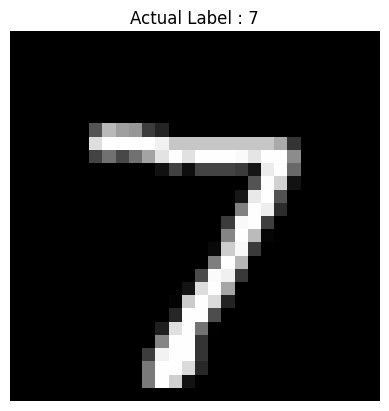

User picked image index 0
Actual Label 7
Model Prediction 7


In [10]:
index = 0
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label : {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print("User picked image index", index)
print("Actual Label", true_label)
print("Model Prediction", predicted_label)